## Experimentation

## Imports

In [1]:
from BoardDetection.BoardDetector_YOLO.BoardDetector_YOLO import BoardDetector_YOLO

import numpy as np
from matplotlib import pyplot as plt
from PIL import Image
import cv2

import torch
from torchvision import transforms

from sklearn.decomposition import PCA
from sklearn.cluster import DBSCAN

import os
from Dataset.data import DataPath

## Constants

In [2]:
bd = BoardDetector_YOLO()

def detect_board_img(img):
    bd.set_img(img)
    mask, conf = bd.predict()
    return mask, conf

## Loading Image

In [3]:
transform = transforms.Compose([
    transforms.ToTensor()
])
filename = '/mnt/D/University/Thesis_Dataset/Dataset/Images/image_280.jpg'
# img_pill = Image.open(os.path.join(DataPath, "data_manual/1741715439429.jpg")).convert("RGB")
# img_pill = Image.open(os.path.join(DataPath, "/mnt/D/University/Thesis_Dataset/Pi_Dataset/dataset3/Images/image_39.jpg")).convert("RGB").resize((640,640))
img_pill = Image.open(os.path.join(DataPath, filename)).convert("RGB").resize((640,640))
# img_pill = Image.open("../data/image_0.jpg").convert("RGB").resize((640,640))
img_gray = transform(img_pill.convert("L")).squeeze()
img: torch.Tensor = transform(img_pill)
img.shape, img.dtype, img.max(), img.min(), img_gray.shape, img_gray.dtype, img_gray.max(), img_gray.min()

(torch.Size([3, 640, 640]),
 torch.float32,
 tensor(1.),
 tensor(0.),
 torch.Size([640, 640]),
 torch.float32,
 tensor(1.),
 tensor(0.))

## YOLO Segmentation

In [4]:
# img_tmp = (img.permute(1,2,0) * 255).to(torch.uint8)
img_tmp = img.clone().detach()
mask, conf = detect_board_img(img_tmp)
conf

0.9440618753433228

((640, 640), torch.Size([640, 640]))

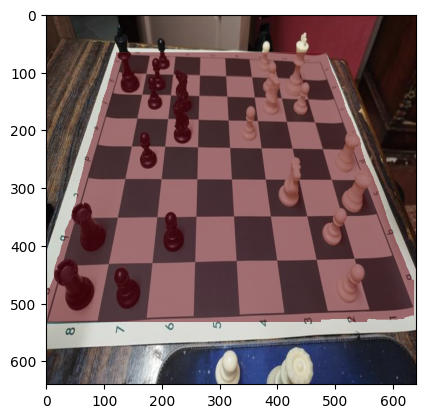

In [5]:
mask_tmp = transform(Image.fromarray(mask).resize((img.shape[2], img.shape[1]))).squeeze()
mask_tmp[mask_tmp < .1] = 0
mask_tmp[mask_tmp > 1] = 1
plt.imshow(img.permute(1,2,0));
plt.imshow(mask_tmp, alpha=mask_tmp*.5, cmap="Reds");
mask.shape, mask_tmp.shape

## Saddle Point Detection

In [6]:
def getSaddle(gray_img):
    d = 1
    k = 3
    img = gray_img.astype(np.float64)
    gx = cv2.Sobel(img,cv2.CV_64F,d,0, ksize=k)
    gy = cv2.Sobel(img,cv2.CV_64F,0,d, ksize=k)
    gxx = cv2.Sobel(gx,cv2.CV_64F,d,0, ksize=k)
    gyy = cv2.Sobel(gy,cv2.CV_64F,0,d, ksize=k)
    gxy = cv2.Sobel(gx,cv2.CV_64F,0,d, ksize=k)

    S = gxx*gyy - gxy**2
    return S

def nonmax_suppression(S, thresh=0.1, window_size=5):
    # Take absolute value for saddle strength
    S_abs = np.abs(S)
    
    # Normalize to [0,1]
    S_norm = S_abs / S_abs.max()

    # Threshold
    mask = S_norm > thresh

    # Dilation to find local maxima
    dilated = cv2.dilate(S_norm, np.ones((window_size, window_size), np.uint8))
    local_max = (S_norm == dilated)

    # Keep only local maxima above threshold
    final_mask = mask & local_max

    # Get coordinates
    pts = np.column_stack(np.nonzero(final_mask))[:,[1,0]]
    return pts, final_mask

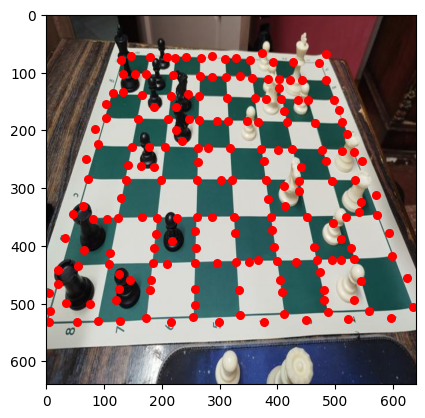

In [7]:
# S = getSaddle((img_gray * mask_tmp).numpy())
S = getSaddle((img_gray).numpy())
S *= mask_tmp.numpy()
S = -S
S[S<0] = 0
pts, S_sup = nonmax_suppression(S, .01, 30)

plt.imshow(img.permute(1,2,0));
plt.scatter(pts[:,0], pts[:,1], c='r', s=30);

## Estimating Board

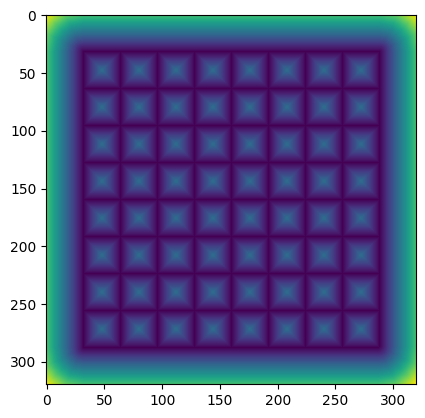

In [46]:
ideal_board = np.ones((256+64,256+64), dtype=np.uint8)
# ideal_board[::32,::32] = 0
ideal_board[32:289:32,32:288] = 0
ideal_board[32:288,32:289:32] = 0
ideal_dist = cv2.distanceTransform(ideal_board, cv2.DIST_L2, 5)

gy, gx = np.gradient(ideal_dist)

# plt.imshow(ideal_board);
plt.imshow(ideal_dist);
# plt.imshow(-gx);
# plt.imshow(-gy);

In [329]:
# p = np.array([[300,70]], dtype=np.float32)
# p = np.random.rand(100, 2) * 320

# Create grid
ys, xs = np.meshgrid(np.arange(320), np.arange(320), indexing='ij')

# Stack into (N, 2)
coords = np.stack([xs.ravel(), ys.ravel()], axis=1)

p = coords

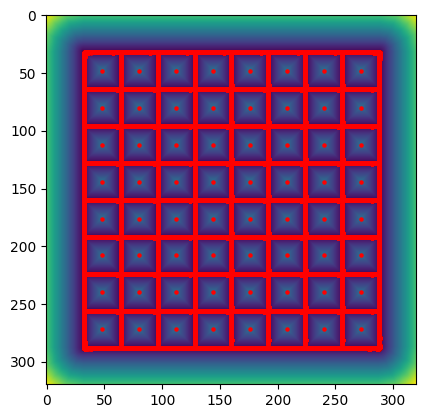

In [391]:
step = .5
p_x = p[:,0]-step*gx[p[:,1].astype(int),p[:,0].astype(int)],
p_new = np.stack([
        p[:,0]-step*gx[p[:,1].astype(int),p[:,0].astype(int)],
        p[:,1]-step*gy[p[:,1].astype(int),p[:,0].astype(int)]
    ], axis=1
)
p = p_new

plt.imshow(ideal_dist);
plt.scatter(p_new[:,0], p_new[:,1], s=5, c='r');

In [607]:
ideal_board = np.ones((256+64,256+64), dtype=np.uint8)
# ideal_board[::32,::32] = 0
ideal_board[32:289:32,32:288] = 0
ideal_board[32:288,32:289:32] = 0
ideal_dist = cv2.distanceTransform(ideal_board, cv2.DIST_L2, 5)

gy, gx = np.gradient(ideal_dist)

src = np.array([
    [130, 78],
    [484, 67],
    [635, 506],
    [4, 532],
], dtype=np.float32
)
dst = np.array([
    [32,32],
    [288,32],
    [288,288],
    [32,288]
], dtype=np.float32)
img_numpy = (img.permute(1,2,0)*255).numpy().astype(np.uint8)

[[  0.0079122      0.2413]
 [   -0.17288     0.13527]
 [   -0.24351     -0.2957]
 [   0.012251    -0.24379]]


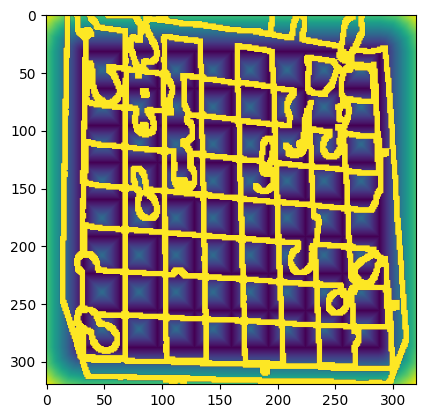

In [656]:
step = 1
iters = 1
for i in range(iters):
    # p_new = np.stack([
    #         p[:,0]-step*gx[p[:,1].astype(int),p[:,0].astype(int)],
    #         p[:,1]-step*gy[p[:,1].astype(int),p[:,0].astype(int)]
    #     ], axis=1
    # )
    M = cv2.getPerspectiveTransform(src, dst)
    img_warped = cv2.warpPerspective(img_numpy, M, (320,320))
    edges = cv2.Canny(img_warped, threshold1=100, threshold2=700);
    edges = cv2.dilate(edges, kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3,3)), iterations=2)
    ys, xs = np.where(edges == 255)
    p = np.stack([xs, ys], axis=1)
    mv = np.stack([
            -step*gx[p[:,1].astype(int),p[:,0].astype(int)],
            -step*gy[p[:,1].astype(int),p[:,0].astype(int)]
        ], dtype=np.float32, axis=1)
    
    mv = np.array([
        mv[(p[:,0]<160) & (p[:,1]<160)].mean(axis=0),
        mv[(p[:,0]>=160) & (p[:,1]<160)].mean(axis=0),
        mv[(p[:,0]>=160) & (p[:,1]>=160)].mean(axis=0),
        mv[(p[:,0]<160) & (p[:,1]>=160)].mean(axis=0),
    ])

    print(mv)
    
    src = cv2.perspectiveTransform((dst + mv).reshape(1,-1,2), np.linalg.inv(M)).reshape(-1,2)

plt.imshow(ideal_dist);
plt.imshow(edges, alpha=edges/255);
# plt.scatter(p_new[:,0], p_new[:,1], s=5, c='r');

# plt.imshow(img_numpy);
# plt.scatter(src[:,0], src[:,1]);

# Method 2

In [318]:
def pad_to_quad(points):
    """
    Pad points to 4 if less than 4 points.
    """
    points = np.array(points, dtype=np.float32)
    
    while len(points) < 4:
        # Duplicate last point
        points = np.vstack([points, points[-1:]])
    
    return points[:4]

def convex_hull_to_quad(points):
    """
    Get convex hull and simplify to a 4-point quad that's reasonably tight.
    Uses polygon approximation (RDP algorithm) to reduce convex hull vertices.
    
    Args:
        points: Array of points (N, 2)
    
    Returns:
        quad: 4-point quad covering the points
    """
    points = np.array(points, dtype=np.float32)
    
    # Get convex hull
    hull = cv2.convexHull(points)
    hull = hull.reshape(-1, 2)
    
    print(f"Convex hull points: {len(hull)}")
    
    # Approximate convex hull to fewer vertices using RDP algorithm
    # epsilon controls tightness - smaller = more points, larger = fewer points
    hull_perimeter = cv2.arcLength(hull, True)
    epsilon = 0.02 * hull_perimeter  # Adjust this value for tightness
    
    simplified = cv2.approxPolyDP(hull, epsilon, True)
    simplified = simplified.reshape(-1, 2)
    
    print(f"Simplified hull points: {len(simplified)}")
    
    if len(simplified) == 4:
        # Already 4 points, return as is
        return np.float32(simplified)
    
    elif len(simplified) > 4:
        # Too many points, get 4 extreme corners
        return get_quad_from_hull(simplified)
    
    else:
        # Less than 4 points, pad with extremes
        return pad_to_quad(simplified)

def get_quad_from_hull(hull):
    """
    Extract 4 extreme corners from convex hull polygon.
    Finds: top-left, top-right, bottom-right, bottom-left
    """
    hull = np.array(hull, dtype=np.float32)
    
    x = hull[:, 0]
    y = hull[:, 1]
    
    # Find extreme corners
    top_left_idx = np.argmin(x + y)      # min sum = top-left
    top_right_idx = np.argmin(-x + y)    # min(-x+y) = top-right
    bottom_right_idx = np.argmax(x + y)  # max sum = bottom-right
    bottom_left_idx = np.argmax(x - y)   # max(x-y) = bottom-left
    
    quad = np.array([
        hull[top_left_idx],
        hull[top_right_idx],
        hull[bottom_right_idx],
        hull[bottom_left_idx]
    ], dtype=np.float32)
    
    return quad

Convex hull points: 12
Simplified hull points: 4
[[        130          78]
 [        484          67]
 [        635         506]
 [          4         532]]


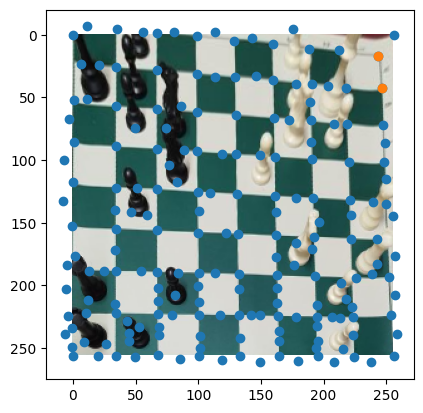

In [319]:
quad = convex_hull_to_quad(pts)

def _order_points_rotation_proof(pts):
        pts = np.array(pts, dtype="float32")
        center = np.mean(pts, axis=0)

        # Compute angle for each point relative to center
        angles = np.arctan2(pts[:, 1] - center[1], pts[:, 0] - center[0])

        # Sort points by angle (counterclockwise)
        ordered = pts[np.argsort(angles)]

        # After sorting by angle, determine which is top-left
        # Top-left = smallest x+y among points
        topmost_index = np.argmin(ordered.sum(axis=1))
        ordered = np.roll(ordered, -topmost_index, axis=0)

        return ordered

src = _order_points_rotation_proof(quad).astype(np.float32)
print(src)
dst = np.array([
    [0,0],
    [256,0],
    [256,256],
    [0,256]
], dtype=np.float32)

img_numpy = (img.permute(1,2,0)*255).to(torch.uint8).numpy()
M = cv2.getPerspectiveTransform(src, dst)
img_warped = cv2.warpPerspective(img_numpy, M, (256,256))
warpped_pts = cv2.perspectiveTransform(pts.reshape(-1, 1, 2).astype(np.float32), M).reshape(-1,2)

bin_size=16
bins = []
for i in range(9):
    bins.append([])
    for j in range(9):
        bins[i].append([])
        bins[i][j] = warpped_pts[(warpped_pts[:,0] <= (i*32+bin_size)) & (warpped_pts[:,0] >= (i*32-bin_size)) & (warpped_pts[:,1] <= (j*32+bin_size)) & (warpped_pts[:,1] >= (j*32-bin_size))]

plt.imshow(img_warped);
plt.scatter(warpped_pts[:,0], warpped_pts[:,1]);
plt.scatter(bins[8][1][:,0], bins[8][1][:,1]);

# plt.imshow(img.permute(1,2,0));
# plt.scatter(pts[:,0], pts[:,1]);
# plt.scatter(quad[:,0], quad[:,1]);

# New Method

In [17]:
coords = np.arange(0, 257, 32, dtype=np.float32)
xx, yy = np.meshgrid(coords, coords)
ideal_board = np.stack([xx.flatten(), yy.flatten()], axis=1)

In [74]:
def hierarchical_ransac_chessboard(pts, ideal_board, outer_iters=5, inner_iters=100, 
                                    search_radius=30, ransac_threshold=10.0):
    """
    Hierarchical RANSAC for chessboard detection.
    
    1. Split points into 4 quadrants (top-left, top-right, bottom-left, bottom-right)
    2. Sample 4 points (one from each quadrant) and map to outer 4 ideal corners
    3. Score each hypothesis against all 81 ideal points
    4. Keep best 4 corners and repeat with refined search region
    
    Args:
        pts: Detected points (N, 2)
        ideal_board: 81 ideal grid points (81, 2)
        outer_iters: Number of outer iterations (refinement loops)
        inner_iters: Number of random samples per outer iteration
        search_radius: Search radius around best points for next iteration
        ransac_threshold: Distance threshold for scoring
    
    Returns:
        best_homography: Best found homography
        best_corners: Best 4 outer corners
        best_score: Score of best solution
    """
    
    pts = pts.astype(np.float32)
    ideal_board = ideal_board.astype(np.float32)
    
    # Get outer 4 ideal corners
    coords = np.arange(0, 256, 32, dtype=np.float32)
    ideal_outer = np.array([
        [0, 0],           # top-left
        [255, 0],         # top-right
        [255, 255],       # bottom-right
        [0, 255]          # bottom-left
    ], dtype=np.float32)
    
    best_homography = None
    best_corners = None
    best_score = 0
    
    # Split into quadrants ONCE at the beginning
    initial_quadrants = split_into_quadrants(pts)
    current_quadrants = [q.copy() for q in initial_quadrants]
    
    for outer_iter in range(outer_iters):
        print(f"\n--- Outer iteration {outer_iter + 1}/{outer_iters} ---")
        print(f"Quadrant sizes: {[len(q) for q in current_quadrants]}")
        
        quadrants = current_quadrants
        
        print(f"Quadrant sizes: {[len(q) for q in quadrants]}")
        
        # Store best corner for each quadrant independently
        best_corners_per_quadrant = [None] * 4
        best_scores_per_quadrant = [0] * 4
        
        # Inner loop: try random samples for each quadrant INDEPENDENTLY
        for inner_iter in range(inner_iters):
            # Pick one random point from each quadrant
            sample_corners = []
            skip_iter = False
            for q_idx, quadrant in enumerate(quadrants):
                if len(quadrant) > 0:
                    idx = np.random.randint(0, len(quadrant))
                    sample_corners.append(quadrant[idx])
                else:
                    sample_corners.append(None)
                    skip_iter = True
            
            # if None in sample_corners:
            if skip_iter:
                continue
            
            sample_corners = np.array(sample_corners)
            
            # Score each corner independently against its quadrant
            quadrant_scores = []
            for q_idx in range(4):
                # Get ideal points for this quadrant (9 points per 3x3 region)
                ideal_quadrant = get_ideal_quadrant(ideal_board, q_idx)
                
                # Map one ideal point (corner) to detected point
                corner_point = sample_corners[q_idx:q_idx+1]
                ideal_corner = ideal_outer[q_idx:q_idx+1]
                
                # Simple homography: just scale/translate to map this corner
                # Score by checking how many quadrant points map close to detected
                score = score_corner_with_quadrant(
                    ideal_quadrant, corner_point, ideal_corner, 
                    quadrants[q_idx], best_corners_per_quadrant,
                    threshold=ransac_threshold
                )
                quadrant_scores.append(score)
                
                if score > best_scores_per_quadrant[q_idx]:
                    best_scores_per_quadrant[q_idx] = score
                    best_corners_per_quadrant[q_idx] = corner_point[0]
        
        # Assemble best corners from each quadrant
        iteration_best_corners = np.array(best_corners_per_quadrant)
        iteration_best_score = sum(best_scores_per_quadrant)
        
        # Compute final homography from best corners
        try:
            iteration_best_homography = cv2.getPerspectiveTransform(ideal_outer, iteration_best_corners)
        except:
            iteration_best_homography = None
        
        print(f"Best scores per quadrant: {best_scores_per_quadrant}")
        print(f"Total score this iteration: {iteration_best_score}")
        
        if iteration_best_score > best_score:
            best_score = iteration_best_score
            best_homography = iteration_best_homography
            best_corners = iteration_best_corners
        
        # Refine search region for next iteration
        if iteration_best_corners is not None:
            current_quadrants = refine_quadrants(
                current_quadrants, iteration_best_corners, search_radius
            )
    
    print(f"\n=== Final Result ===")
    print(f"Best score: {best_score}/{len(ideal_board)}")
    print(f"Best corners:\n{best_corners}")
    
    return best_homography, best_corners, best_score


def split_into_quadrants(pts):
    """
    Split points into 4 quadrants using PCA.
    
    Returns 4 quadrants: [top-left, top-right, bottom-right, bottom-left]
    """
    if len(pts) < 4:
        return [pts, [], [], []]
    
    # Use PCA to find principal axes
    pca = PCA(n_components=2)
    pca.fit(pts)
    
    # Project points onto principal components
    projected = pca.transform(pts)
    
    # Split by median
    median_x = np.median(projected[:, 0])
    median_y = np.median(projected[:, 1])
    
    # Map back to original indices
    left = projected[:, 0] < median_x
    right = projected[:, 0] >= median_x
    top = projected[:, 1] < median_y
    bottom = projected[:, 1] >= median_y
    
    quadrants = [
        pts[left & top],      # top-left
        pts[right & top],     # top-right
        pts[right & bottom],  # bottom-right
        pts[left & bottom]    # bottom-left
    ]
    
    return quadrants


def get_ideal_quadrant(ideal_board, quadrant_idx):
    """
    Get ideal points for a specific quadrant (3x3 grid of points).
    Quadrants: 0=top-left, 1=top-right, 2=bottom-right, 3=bottom-left
    """
    grid_2d = ideal_board.reshape(9, 9, 2)
    
    if quadrant_idx == 0:  # top-left
        return grid_2d[:3, :3].reshape(-1, 2)
    elif quadrant_idx == 1:  # top-right
        return grid_2d[:3, 6:].reshape(-1, 2)
    elif quadrant_idx == 2:  # bottom-right
        return grid_2d[6:, 6:].reshape(-1, 2)
    else:  # bottom-left
        return grid_2d[6:, :3].reshape(-1, 2)


def score_corner_with_quadrant(ideal_quadrant, detected_corner, ideal_corner, 
                               detected_quadrant, best_corners_per_quadrant=None,
                               threshold=10.0, area_weight=0.1):
    """
    Score a single corner by transforming detected points to ideal space
    and comparing there.
    
    This is more stable than comparing in real space because the ideal space
    is always the same grid pattern.
    """
    if len(detected_quadrant) == 0:
        return 0
    
    # Compute inverse transformation: real space -> ideal space
    # Simple approach: estimate scale and rotation from corner mapping
    translation = detected_corner - ideal_corner
    
    # Transform detected quadrant points to ideal space
    # (subtract translation to align the corner)
    detected_in_ideal = detected_quadrant - translation
    
    # Count how many detected points (in ideal space) are close to ideal quadrant points
    match_score = 0
    for ideal_pt in ideal_quadrant:
        distances = np.linalg.norm(detected_in_ideal - ideal_pt, axis=1)
        if np.min(distances) < threshold:
            match_score += 1
    
    # Bonus: maximize area by preferring corners that are far from center
    # and far from other best corners found so far
    area_score = 0.0
    
    if best_corners_per_quadrant is not None and any(c is not None for c in best_corners_per_quadrant):
        # Distance from image center (128, 128)
        dist_from_center = np.linalg.norm(detected_corner - np.array([128, 128]))
        area_score += dist_from_center * area_weight
        
        # Distance from other best corners
        for other_corner in best_corners_per_quadrant:
            if other_corner is not None:
                area_score += np.linalg.norm(detected_corner - other_corner) * area_weight * 0.1
    
    total_score = match_score + area_score
    
    return total_score


def refine_quadrants(quadrants, best_corners, radius):
    """
    Refine each quadrant by keeping only points within 'radius' of corresponding corner.
    Quadrants order: [top-left, top-right, bottom-right, bottom-left]
    Corners order: same
    """
    refined_quadrants = []
    for i, quadrant in enumerate(quadrants):
        corner = best_corners[i]
        refined = quadrant[
            np.linalg.norm(quadrant - corner, axis=1) < radius
        ]
        if len(refined) > 0:
            refined_quadrants.append(refined)
        else:
            refined_quadrants.append(quadrant)  # Keep original if empty
    
    return refined_quadrants

In [78]:
# Run hierarchical RANSAC
H, corners, score = hierarchical_ransac_chessboard(
    pts, ideal_board,
    outer_iters=10,
    inner_iters=100,
    search_radius=20
)


--- Outer iteration 1/10 ---
Quadrant sizes: [64, 67, 64, 67]
Quadrant sizes: [64, 67, 64, 67]
Best scores per quadrant: [np.float64(41.706593454576705), np.float64(61.43035167382168), np.float64(79.82573708536522), np.float64(65.40691454343613)]
Total score this iteration: 248.36959675719976

--- Outer iteration 2/10 ---
Quadrant sizes: [3, 2, 3, 1]
Quadrant sizes: [3, 2, 3, 1]
Best scores per quadrant: [np.float64(41.33909928391171), np.float64(52.883416413525815), np.float64(78.45115475001232), np.float64(58.886738251970364)]
Total score this iteration: 231.56040869942024

--- Outer iteration 3/10 ---
Quadrant sizes: [3, 2, 3, 1]
Quadrant sizes: [3, 2, 3, 1]
Best scores per quadrant: [np.float64(41.264068197109225), np.float64(52.65709686205792), np.float64(78.20883254351513), np.float64(59.011915396974636)]
Total score this iteration: 231.14191299965694

--- Outer iteration 4/10 ---
Quadrant sizes: [3, 2, 3, 1]
Quadrant sizes: [3, 2, 3, 1]
Best scores per quadrant: [np.float64(41.

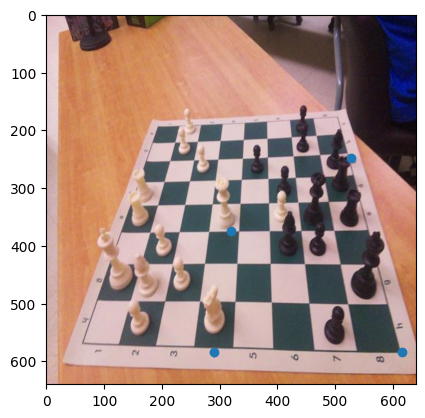

In [79]:
plt.imshow(img.permute(1,2,0));
# plt.scatter(pts[:,0], pts[:,1]);
plt.scatter(corners[:,0], corners[:,1]);

pts_split = split_into_quadrants(pts)

# for i in range(4):
#     plt.scatter(pts_split[i][:,0], pts_split[i][:,1]);

In [160]:
def make_chessboard_model(cols, rows, square_size=1.0):
    # cols = number of inner corners horizontally
    # rows = number of inner corners vertically
    model_pts = []
    for y in range(rows):
        for x in range(cols):
            model_pts.append((x * square_size, y * square_size))
    return np.array(model_pts, dtype=np.float32)

model_pts = make_chessboard_model(7, 7)

def spatially_filter_points(pts, strengths, min_dist=10):
    """
    pts: Nx2 array (x, y)
    strengths: list/array of N scores (higher = stronger)
    min_dist: minimum distance in pixels between kept points
    """
    # Sort by strength descending
    order = np.argsort(strengths)[::-1]
    pts_sorted = pts[order]
    strengths_sorted = strengths[order]

    kept = []
    for p in pts_sorted:
        if all(np.linalg.norm(p - np.array(k)) >= min_dist for k in kept):
            kept.append(p)
    return np.array(kept, dtype=np.float32)

def align_points_with_pca_snapped(pts):
    mean = np.mean(pts, axis=0)
    centered = pts - mean

    cov = np.cov(centered.T)
    eigvals, eigvecs = np.linalg.eigh(cov)
    order = np.argsort(eigvals)[::-1]
    eigvecs = eigvecs[:, order]

    # Angle of first eigenvector
    angle = np.arctan2(eigvecs[1, 0], eigvecs[0, 0])
    
    # Snap to nearest 90°
    snap_angle = np.round(angle / (np.pi/2)) * (np.pi/2)
    
    # Final rotation angle
    rot_angle = angle - snap_angle

    # Rotation matrix
    R = np.array([
        [np.cos(-rot_angle), -np.sin(-rot_angle)],
        [np.sin(-rot_angle),  np.cos(-rot_angle)]
    ])

    rotated = centered @ R.T
    return rotated, R, mean

def plot_pca_axes(img_pts, eigvecs, mean, scale=100):
    """
    img_pts: Nx2 array of (x, y) points in image coordinates
    eigvecs: 2x2 array, columns are eigenvectors from PCA
    mean: 2-element array, the center of the points
    scale: length of drawn axes in pixels
    """
    plt.figure(figsize=(6,6))
    plt.scatter(img_pts[:,0], img_pts[:,1], c='red', s=40, label='Saddle points')
    plt.scatter(mean[0], mean[1], c='blue', s=80, marker='x', label='Center')

    # Draw first principal axis
    plt.arrow(mean[0], mean[1],
              eigvecs[0,0]*scale, eigvecs[1,0]*scale,
              color='green', width=2, label='1st PCA axis')

    # Draw second principal axis
    plt.arrow(mean[0], mean[1],
              eigvecs[0,1]*scale, eigvecs[1,1]*scale,
              color='orange', width=2, label='2nd PCA axis')

    plt.gca().invert_yaxis()  # to match image coordinates
    plt.gca().set_aspect('equal', adjustable='box')
    plt.legend()
    plt.title("PCA Axes on Detected Saddle Points")
    plt.show()


def cluster_points_dbscan(pts, eps=10, min_samples=1):
    """
    pts: Nx2 array of (x, y)
    eps: max distance for points to be in same cluster (pixels)
    min_samples: min points to form a cluster
    """
    clustering = DBSCAN(eps=eps, min_samples=min_samples).fit(pts)
    labels = clustering.labels_
    return labels  # same index as pts

def filter_points_by_clustering(pts, strengths, eps=10, min_samples=1):
    """
    Filter points by clustering nearby detections and keeping the strongest in each cluster.
    
    Parameters
    ----------
    pts : ndarray of shape (N, 2)
        (x, y) coordinates of detected points in pixels.
    strengths : array-like of shape (N,)
        Scores/strengths for each point (higher = stronger).
    eps : float
        Maximum distance in pixels for points to be in the same cluster.
    min_samples : int
        Minimum number of points to form a cluster (DBSCAN parameter).
    
    Returns
    -------
    filtered_pts : ndarray of shape (M, 2)
        Filtered points, one per cluster.
    """
    # Run DBSCAN clustering
    clustering = DBSCAN(eps=eps, min_samples=min_samples).fit(pts)
    labels = clustering.labels_

    filtered_pts = []
    for lbl in np.unique(labels):
        if lbl == -1:  # noise points — keep them as their own
            noise_pts = pts[labels == lbl]
            noise_strengths = np.array(strengths)[labels == lbl]
            # Keep the strongest noise point (usually just 1 point)
            best_idx = np.argmax(noise_strengths)
            filtered_pts.append(noise_pts[best_idx])
        else:
            cluster_pts = pts[labels == lbl]
            cluster_strengths = np.array(strengths)[labels == lbl]
            best_idx = np.argmax(cluster_strengths)
            filtered_pts.append(cluster_pts[best_idx])

    return np.array(filtered_pts, dtype=np.float32)

array([     1582.4,      1429.7])

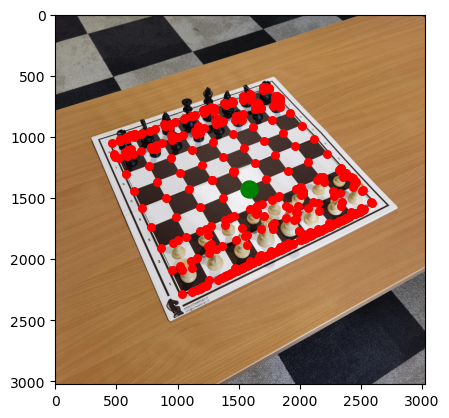

In [173]:
plt.imshow(img.permute(1,2,0));
plt.scatter(pts[:,0], pts[:,1], c='r', s=30);

mean = pts.mean(axis=0)
plt.scatter(mean[0], mean[1], c='g', s=150);
mean

In [162]:
# Get strengths from your saddle score map S
strengths = np.abs([S[y, x] for y, x in pts])

# Filter out clustered points
filtered_pts = filter_points_by_clustering(pts, strengths, eps=12)

# Now you can safely run PCA
new_pts, eigvecs, mean = align_points_with_pca_snapped(filtered_pts)

array([     1441.3,        1338], dtype=float32)

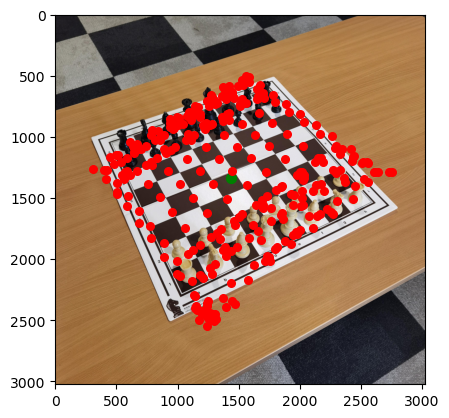

In [ ]:
# strengths = np.abs([S[x,y] for x, y in pts])
# kept = spatially_filter_points(pts, strengths)
# new_pts, _, mean = align_points_with_pca_snapped(kept)

# rotated_pts, eigvecs, mean = align_points_with_pca_snapped(kept)
# plot_pca_axes(pts, eigvecs, mean, scale=1500)

new_pts = new_pts + mean

plt.imshow(img.permute(1,2,0));
plt.scatter(mean[0], mean[1], c='g', s=50)
# plt.scatter(kept[:,0], kept[:,1], c='r', s=30);
plt.scatter(new_pts[:,0], new_pts[:,1], c='r', s=30);
mean

In [ ]:
cv2.findHomography(src, dst, cv2.RANSAC)

In [159]:
def fit_and_draw_filled_square(img, pts, color=(0, 255, 0), alpha=0.4):
    """
    Fits a square/rectangle to pts and draws it filled on img.
    img: BGR image
    pts: Nx2 (x, y) array
    color: fill color in BGR
    alpha: transparency for the fill
    """
    # Convex hull
    hull = cv2.convexHull(pts.astype(np.float32))
    # plt.scatter(hull[:,0,0], hull[:,0,1], c='b', s=50, zorder=3);

    epsilon = 0.02 * cv2.arcLength(hull, True)  # 2% of perimeter
    quad = cv2.approxPolyDP(hull, epsilon, True)

    quad = quad.reshape(-1, 2)  # (4,2) if it found a quadrilateral
    print(quad)

    # # Fit min area rectangle
    # rect = cv2.minAreaRect(hull)
    # box = cv2.boxPoints(rect)  # 4 corners
    # box = np.int32(box)

    # # Create overlay for transparency
    # overlay = img.copy()
    # cv2.fillPoly(overlay, [box], color)

    # # Blend overlay with original
    # cv2.addWeighted(overlay, alpha, img, 1 - alpha, 0, img)

    # # Optionally draw rectangle outline
    # cv2.polylines(img, [box], isClosed=True, color=(0, 0, 255), thickness=2)

    # return img, box
    return quad

def best_fit_quad(pts):
    # Step 1: convex hull
    hull = cv2.convexHull(pts)

    # Step 2: try different epsilons to get 4 vertices
    best_quad = None
    best_score = -1

    for eps_factor in np.linspace(0.001, 0.05, 50):
        approx = cv2.approxPolyDP(hull, eps_factor * cv2.arcLength(hull, True), True)
        if len(approx) == 4:
            quad = approx.reshape(4, 2)

            # Step 3: create mask and count coverage
            mask = np.zeros((img.shape[2], img.shape[1]), dtype=np.uint8)  # adjust size if needed
            scaled_quad = np.int32(quad)  # Ensure int
            cv2.fillPoly(mask, [scaled_quad], 255)

            # Scale/shift points into mask coordinates
            min_xy = pts.min(axis=0)
            shifted_pts = (pts - min_xy).astype(int)
            shifted_quad = (quad - min_xy).astype(int)
            mask = np.zeros((shifted_pts[:,1].max()+5, shifted_pts[:,0].max()+5), dtype=np.uint8)
            cv2.fillPoly(mask, [shifted_quad], 255)

            coverage = np.sum(mask[shifted_pts[:,1], shifted_pts[:,0]] > 0)

            # Score = coverage + area importance
            area = cv2.contourArea(shifted_quad)
            score = coverage + 0.001 * area

            if score > best_score:
                best_score = score
                best_quad = quad

    return best_quad

array([[629, 574],
       [ 40, 584],
       [164, 173],
       [484, 172]], dtype=int32)

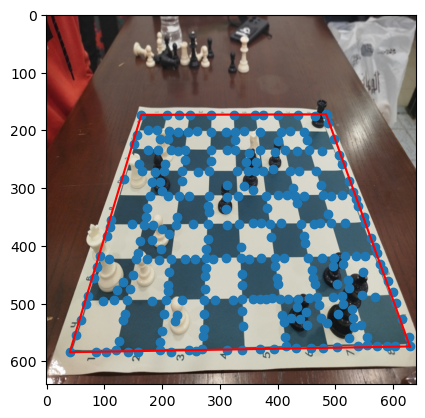

In [160]:
quad = best_fit_quad(pts)
plt.imshow(img.permute(1,2,0))
plt.scatter(*zip(*pts))
plt.plot(*zip(*(list(quad) + [quad[0]])), 'r-');
quad

## Test

In [2]:
import sys
sys.path.append("/mnt/D/University/Thesis/src")

In [12]:
from BoardDetection.BoardDetector_YOLO_Saddle import Bounded_Saddle_Yolo

import os

from torchvision import transforms
import numpy as np
from matplotlib import pyplot as plt
from PIL import Image

import importlib
importlib.reload(Bounded_Saddle_Yolo);

from Dataset.data import DataPath
from Dataset.DataSetLoaders.ChessDataset import ChessDataset

In [13]:
transform = transforms.Compose([
    transforms.ToTensor()
])

In [ ]:
# img_path = os.path.join(DataPath, "data2/image4.jpg")
# img_path = os.path.join(DataPath, "data_manual/1741715439516.jpg")
# img_path = os.path.join(DataPath, "data_old/44.jpeg")
# img_path = os.path.join(DataPath, "data_manual/full_dataset/manual_dataset/images/img26.jpg")
# img = transform(Image.open(img_path).convert("RGB").resize((640,640)))

dataset = ChessDataset(
    config={"img_size": (640,640)}
)
img, y = dataset[0]

torch.Size([3, 640, 640]) torch.float32 tensor(1.) tensor(0.)


In [40]:
BE = Bounded_Saddle_Yolo.BoardExtractor()
BE.set_img(img)

In [41]:
quad, conf = BE.extract_board()
conf

np.float64(0.911511818489068)

array([[        144,         100],
       [        477,          90],
       [        624,         501],
       [         25,         525]], dtype=float32)

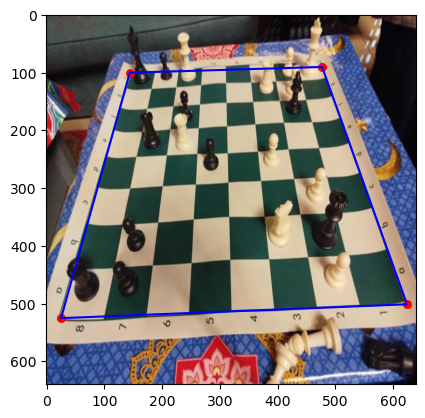

In [42]:
plt.imshow(img.permute(1,2,0))
plt.plot(*zip(*(list(quad) + [quad[0]])), 'b-');
plt.scatter(*zip(*quad), c='r', s=30);
quad

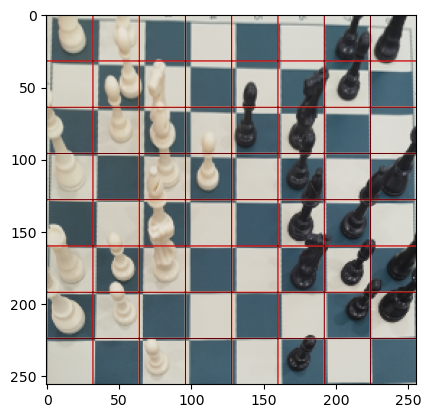

In [25]:
warpped, M = BE.warp(quad)

grid = np.zeros((256,256))
step = 32
# Set pixels in rows and columns that are multiples of step to 1
grid[::step, :] = 1   # horizontal lines
grid[:, ::step] = 1   # vertical lines

plt.imshow(warpped);
plt.imshow(grid, alpha=grid, cmap='Reds');